In [ ]:
"""
            Indian Weather Dataset Exploratory Data Analysis (EDA)
    This notebook performs historical data exploration on our Indian weather tracking database.
    It analyzes foundational climate variables across different cities and checks dependencies before building the final predictive machine learning pipeline.
"""


In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set Times New Roman and professional formatting for embedded plots
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

print("All analysis dependencies successfully initialized.")

All analysis dependencies successfully initialized.


In [2]:
# Connect to the operational SQLite database from the parent tracking folder
db_path = os.path.join('..', 'data', 'weather_data.db')

conn = sqlite3.connect(db_path)
query = "SELECT Date, City, Temperature, Humidity, Rainfall, WindSpeed FROM india_weather"
df = pd.read_sql_query(query, conn)
conn.close()

# Safe data transformations
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.strftime('%B')

print(f"Data successfully fetched. Shape of dataset: {df.shape}")

Data successfully fetched. Shape of dataset: (1460, 7)


In [8]:
# Check structural information and summary properties with custom Times New Roman output
from IPython.display import display, HTML

print("--- Structural Information ---")
df.info()

print("\n--- Missing Values Audit ---")
print(df.isnull().sum())

print("\n--- First 5 Rows (Formatted in Times New Roman) ---")
# Select the first 5 rows of your weather data
sample_df = df.head(5)

# Render the dataframe with embedded CSS styling overrides
display(HTML(f"""
<style>
    .dataframe th, .dataframe td {{
        font-family: 'Times New Roman', serif !important;
        font-size: 13px !important;
        padding: 6px !important;
        text-align: left !important;
    }}
</style>
{sample_df.to_html(index=False)}
"""))

--- Structural Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1460 non-null   datetime64[ns]
 1   City         1460 non-null   object        
 2   Temperature  1460 non-null   float64       
 3   Humidity     1460 non-null   int64         
 4   Rainfall     1460 non-null   float64       
 5   WindSpeed    1460 non-null   float64       
 6   Month        1460 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 80.0+ KB

--- Missing Values Audit ---
Date           0
City           0
Temperature    0
Humidity       0
Rainfall       0
WindSpeed      0
Month          0
dtype: int64

--- First 5 Rows (Formatted in Times New Roman) ---


Date,City,Temperature,Humidity,Rainfall,WindSpeed,Month
2025-01-01,Delhi,13.4,63,0.0,8.7,January
2025-01-01,Mumbai,25.4,60,0.0,8.1,January
2025-01-01,Bangalore,27.8,38,0.0,7.9,January
2025-01-01,Kolkata,20.5,58,0.0,21.6,January
2025-01-02,Delhi,11.6,55,0.0,17.3,January


In [9]:
from IPython.display import display, HTML

print("--- Descriptive Summary (Formatted in Times New Roman) ---")
# Get the transposed descriptive statistics summary
desc_df = df.describe().T.reset_index()
desc_df.rename(columns={'index': 'Metric'}, inplace=True)

# Format the City counts into a clean dataframe structure
city_counts = df['City'].value_counts().reset_index()
city_counts.columns = ['Indian City', 'Total Rows Recorded']

# Render both dataframes with embedded Times New Roman CSS styling overrides
display(HTML(f"""
<style>
    .times-df th, .times-df td {{
        font-family: 'Times New Roman', serif !important;
        font-size: 13px !important;
        padding: 6px 12px !important;
        text-align: left !important;
    }}
    .section-title {{
        font-family: 'Times New Roman', serif !important;
        font-size: 14px !important;
        font-weight: bold !important;
        margin-top: 20px !important;
        margin-bottom: 5px !important;
    }}
</style>

{desc_df.to_html(index=False, classes='times-df')}

<div class="section-title">--- Rows Sample Breakdown per Indian City (Formatted in Times New Roman) ---</div>

{city_counts.to_html(index=False, classes='times-df')}
"""))

--- Descriptive Summary (Formatted in Times New Roman) ---


In [10]:
# Calculate seasonal aggregations to identify micro-climates
city_summary = df.groupby('City').mean(numeric_only=True).reset_index()
print("--- Average Weather Metrics by City ---")
display(city_summary)

# Highlight high-impact outlier events (e.g., heavy rainfall days)
heavy_rain = df[df['Rainfall'] > df['Rainfall'].quantile(0.95)]
print(f"\nCaptured {len(heavy_rain)} high-intensity rainfall anomalies across the observation track.")

--- Average Weather Metrics by City ---


,City,Temperature,Humidity,Rainfall,WindSpeed
0,Bangalore,27.754247,56.942466,1.425753,15.069589
1,Delhi,26.922740,56.676712,1.541918,15.175342
2,Kolkata,29.821644,60.339726,2.124932,15.134795
3,Mumbai,27.714247,60.523288,3.684110,14.914521



Captured 73 high-intensity rainfall anomalies across the observation track.


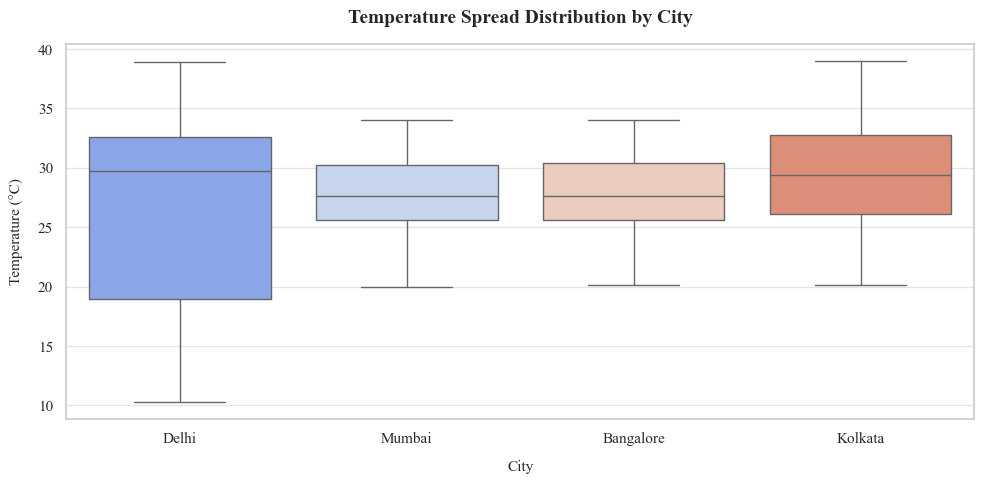

In [11]:
# Visualize Temperature distributions across different cities
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='City', y='Temperature', hue='City', legend=False, palette='coolwarm', ax=ax)
ax.set_title('Temperature Spread Distribution by City', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('City', fontsize=11, labelpad=10)
ax.set_ylabel('Temperature (°C)', fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

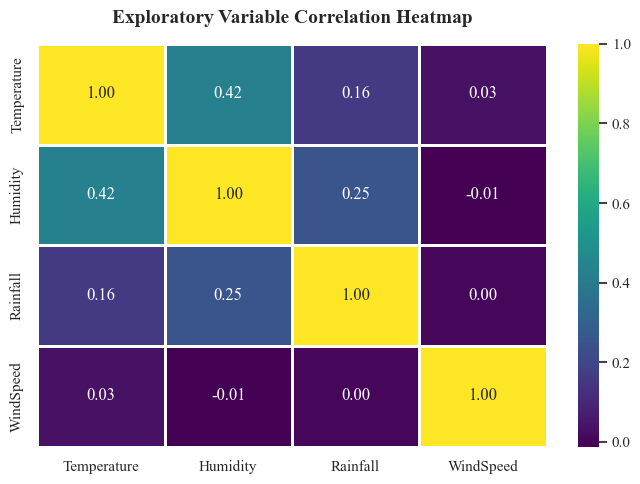

In [12]:
# Display a correlation matrix to confirm feature engineering viability for ML training
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[['Temperature', 'Humidity', 'Rainfall', 'WindSpeed']].corr()
sns.heatmap(corr, annot=True, cmap='viridis', fmt=".2f", linewidths=1, ax=ax)
ax.set_title('Exploratory Variable Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()